# KENYA_SACCO_SIM — Getting Started

A guided tour of the synthetic Kenyan SACCO AML dataset. By the end you will have:

1. Loaded every file the generator emits and understood the schema.
2. Explored members, accounts, transactions, loans, and the labelled alerts.
3. Used the official train / validation / test splits.
4. Reproduced the rule-baseline metrics shipped in `baseline_model_results.json`.
5. Trained a simple ML baseline at the member level.
6. Built and visualized an ego-graph around a suspicious member.

This notebook reads from `datasets/KENYA_SACCO_SIM_v02_10k_review_fix/`. If you do not have it yet, regenerate from the repo root:

```
python3 -m kenya_sacco_sim generate --members 10000 --with-loans --with-typologies --with-benchmark --output ./datasets/KENYA_SACCO_SIM_v02_10k_review_fix
```


<!-- KSS_ASSUMPTIONS -->
## Design assumptions and decisions

The dataset is generated under a frozen **v0.1 specification**, extended by
**v0.2** which adds support entities, institution archetypes, a device
layer, one new typology, and a multi-seed stability harness. The full source
documents are `kenya_sacco_sim_v_0_1_specification.md`,
`kenya_sacco_sim_v_0_2_specification.md`, and `deep-research-report.md`.
Everything in this notebook follows from those three documents.

> **correctness > realism > scale.**
>
> A small, ledger-reconciled, well-labelled dataset is more useful than a
> large unreconciled one. v0.1 froze that contract at 10k members; v0.2
> deepens the world without changing existing file schemas.

### Architectural decisions (carried from v0.1)

- **Pattern-first generation.** No transaction is emitted at random. Every
  ledger event comes from a named behavioural pattern (e.g.
  `SALARY_CHECKOFF_WALLET_SPEND`, `SME_DAILY_RECEIPTS_MONDAY_DEPOSIT`,
  `STRUCTURING`). This is what makes alerts explainable.
- **Graph-first world.** The simulator first materialises a typed graph of
  institutions, members, accounts, wallets, employers, branches, agents,
  devices, sources, and sinks. Transactions are emitted *over* that graph,
  so `nodes.csv` / `graph_edges.csv` are first-class outputs.
- **Deterministic seed hierarchy.** All randomness derives from a single
  `WorldConfig.seed`. Child seeds are computed as
  `institution_seed = hash(global_seed, institution_id)`,
  `member_seed = hash(global_seed, member_id)`,
  `pattern_seed = hash(global_seed, pattern_id)`, so parallel generation
  reproduces bit-identical outputs.
- **Canonical conventions.** `amount_kes` is **always positive**; direction
  is determined only by `account_id_dr` / `account_id_cr`. Timestamps are
  Africa/Nairobi (EAT, UTC+3), ISO-8601. Currency is KES.
- **Compatibility contract (v0.2 §2).** Every v0.1 file is still emitted,
  unchanged in schema. v0.2 only *adds* support files
  (`institutions.csv`, `branches.csv`, `agents.csv`, `employers.csv`,
  `devices.csv`) and four new sections inside `validation_report.json`.

### Mandatory Kenyan SACCO / payment assumptions (v0.1 spec §6)

1. Every formal salaried member has at least one FOSA account.
2. Every normal SACCO member has a BOSA deposit account.
3. Share capital is distinct from deposits.
4. Loan accounts are distinct from FOSA and BOSA accounts.
5. Payroll check-off can split salary into loan repayment, BOSA deposit
   contribution, and net salary to FOSA.
6. M-Pesa / wallet behaviour exists for most members.
7. Guarantor-backed loans exist for development and emergency loans.
8. School-fee seasonality exists in January, May, and August.
9. December has elevated spend / remittance / cash-out activity.
10. Rural members use more cash / agent transactions than urban members.

### Why this is "mobile-money-first"

Kenya is, structurally, a wallet-dominated retail-finance environment. The
research report anchors the simulator to:

- ~82.4M registered mobile-money users and ~36.9M 30-day actives (CBK, Dec 2024).
- 82.3% of adults using mobile money, 52.6% using it **daily**; daily bank
  use only 4.8% (FinAccess 2024).
- 6.84M SASRA-regulated SACCO members, KES 758.6B gross loans, KES 682.2B
  deposits across 357 SACCOs in 2023; 53 SACCOs hold 73% of assets.
- Diaspora remittances of USD 4.945B in 2024, ~51% from the US corridor.

That is why every persona has a wallet propensity, why `MPESA` and
`PESALINK` are first-class rails, and why v0.2 institutions carry an
explicit `digital_maturity` and `cash_intensity` rather than a uniform
prior.

### v0.2 scope additions

- **5 v0.1 normal patterns** are still the only normal-behaviour
  generators: salary check-off + wallet spend, SME daily receipts + Monday
  deposit, farmer seasonal income, diaspora support, loan lifecycle.
- **3 suspicious typologies** are now injected: `STRUCTURING` and
  `RAPID_PASS_THROUGH` (v0.1) plus `FAKE_AFFORDABILITY_BEFORE_LOAN` (v0.2).
- **Configuration is externalised.** Eight YAML files under `config/` drive
  the run (`world.yaml`, `personas.yaml`, `products.yaml`,
  `institutions.yaml`, `patterns.yaml`, `typologies.yaml`, `calendar.yaml`,
  `validation.yaml`); the manifest records which were loaded.
- **Institution archetypes** assign every SACCO one of
  `TEACHER_PUBLIC_SECTOR`, `UNIFORMED_SERVICES`, `UTILITY_PRIVATE_SECTOR`,
  `COMMUNITY_CHURCH`, `FARMER_COOPERATIVE`, `SME_BIASHARA`, or
  `DIASPORA_FACING`, which biases persona mix, channel mix, and loan style.
- **Device layer baseline.** Digital channels (`MOBILE_APP`, `USSD`,
  `PAYBILL`, `TILL`, `BANK_TRANSFER`) populate `device_id`; shared-device
  groups exist at low rates as a baseline (typology-free in v0.2).
- **Multi-seed stability harness.** `python3 -m kenya_sacco_sim benchmark`
  emits `multi_seed_results.json` with per-seed metrics and a stability
  report; the v0.2 release gate is per-typology precision/recall range
  ≤ 0.10 across configured seeds.
- **Deferred to v1**: guarantor rings, dormant reactivation, remittance
  layering, wallet funnels, device-sharing typologies, GNN benchmarks,
  100k+ scale.


## 0. Prerequisites

The generator itself has zero third-party dependencies. This tutorial uses
pandas, scikit-learn, matplotlib, and networkx for analysis only. Install
them once from the repo root:

```bash
pip install -r requirements-notebooks.txt
```

The next cell verifies the environment and aborts with a clear message if
any dependency is missing.


In [1]:
# Preflight: confirm the notebook deps are importable.
import importlib.util

_required = ('pandas', 'sklearn', 'matplotlib', 'networkx')
_missing = [m for m in _required if importlib.util.find_spec(m) is None]
if _missing:
    raise SystemExit(
        f'Missing notebook deps: {_missing}. From the repo root run:\n'
        '    pip install -r requirements-notebooks.txt'
    )
print('All notebook dependencies present.')


All notebook dependencies present.


In [2]:
from pathlib import Path
import json
import pandas as pd

REPO_ROOT   = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATASET_DIR = REPO_ROOT / 'datasets' / 'KENYA_SACCO_SIM_v02_10k_review_fix'
assert DATASET_DIR.exists(), f'Dataset not found at {DATASET_DIR}. Regenerate it first.'
print('Reading from:', DATASET_DIR)


Reading from: /Users/nicholasguantai/code/kenya_sacco_sim/datasets/KENYA_SACCO_SIM_v02_10k_review_fix


## 1. What's in a run

Every generator run emits a fixed set of CSVs and JSON sidecars plus a deterministic `manifest.json` with file hashes.

In [3]:
for p in sorted(DATASET_DIR.iterdir()):
    print(f'{p.stat().st_size:>10,} bytes  {p.name}')


 5,011,025 bytes  accounts.csv
     5,591 bytes  agents.csv
   159,738 bytes  alerts_truth.csv
     6,344 bytes  baseline_model_results.json
       880 bytes  branches.csv
     1,340 bytes  dataset_card.md
   972,807 bytes  devices.csv
     6,950 bytes  employers.csv
    12,582 bytes  feature_documentation.json
41,739,946 bytes  graph_edges.csv
   318,870 bytes  guarantors.csv
       689 bytes  institutions.csv
       593 bytes  known_limitations.md
   443,877 bytes  loans.csv
     2,353 bytes  manifest.json
 2,010,236 bytes  members.csv
 4,440,576 bytes  nodes.csv
    16,326 bytes  rule_results.json
   281,062 bytes  split_manifest.json
140,951,361 bytes  transactions.csv
    35,140 bytes  validation_report.json


In [4]:
manifest = json.loads((DATASET_DIR / 'manifest.json').read_text())
{k: manifest[k] for k in ('dataset_name','version','seed','members','institutions','start_date','end_date','validation')}


{'dataset_name': 'KENYA_SACCO_SIM',
 'version': '0.2.0',
 'seed': 42,
 'members': 10000,
 'institutions': 5,
 'start_date': '2024-01-01',
 'end_date': '2024-12-31',
 'validation': {'error_count': 0, 'warning_count': 0}}

## 2. Members

The member population is partitioned across personas calibrated to Kenyan SACCO realities — salaried teachers, county workers, SME owners, seasonal farmers, diaspora-supported, boda-boda operators, and church organizations.

<!-- KSS_ASSUMPTIONS -->
**Decisions encoded here.** Persona shares, monthly-income tertiles, wallet
adoption probability, rural probability, and annual loan probability are all
fixed in the spec (`personas.yaml`, §7.2) and implemented in
`core.config.PERSONA_CONFIG`. The income tertiles are calibrated so the
formal-salaried cohorts centre near the KNBS 2024 public-sector mean of
**KSh 933.1k / year (≈ KSh 77.8k / month)**:

| Persona | Share | Monthly income tertiles (KES) | Wallet | Rural | Loan p/yr |
|---|---:|---|---:|---:|---:|
| `SALARIED_TEACHER` | 22% | 45k / 78k / 120k | 0.95 | 0.35 | 0.35 |
| `SME_OWNER` | 18% | 30k / 120k / 300k | 0.98 | 0.25 | 0.25 |
| `FARMER_SEASONAL` | 17% | 10k / 35k / 150k | 0.80 | 0.85 | 0.20 |
| `BODA_BODA_OPERATOR` | 15% | 20k / 45k / 80k | 0.98 | 0.40 | 0.22 |
| `COUNTY_WORKER` | 13% | 35k / 65k / 95k | 0.95 | 0.30 | 0.30 |
| `DIASPORA_SUPPORTED` | 10% | 15k / 50k / 180k | 0.95 | 0.45 | 0.15 |
| `CHURCH_ORG` | 5% | 30k / 150k / 600k | 0.90 | 0.50 | 0.10 |

`SHELL_MEMBER` is **deliberately absent**. v0.1 injects suspicious behaviour
into plausible ordinary personas (typically `SME_OWNER`, `BODA_BODA_OPERATOR`,
`DIASPORA_SUPPORTED`, `CHURCH_ORG`) so detectors cannot trivially win by
learning a "criminal persona" feature.


In [5]:
members = pd.read_csv(DATASET_DIR / 'members.csv')
print(f'{len(members):,} members, {members.shape[1]} columns')
members.head(3)


10,000 members, 19 columns


,member_id,institution_id,member_type,persona_type,county,urban_rural,gender,age,occupation,employer_id,join_date,kyc_level,risk_segment,phone_hash,id_hash,declared_monthly_income_kes,income_stability_score,dormant_flag,created_at
0,MEM0000001,INST0005,INDIVIDUAL,BODA_BODA_OPERATOR,Mombasa,RURAL,MALE,67,Boda boda operator,NaN,2019-08-04,STANDARD,LOW,PHONE_174d32d8f0848e16,ID_174d32d8f0848e16,38415,0.807,False,2024-01-01T00:00:00+03:00
1,MEM0000002,INST0001,INDIVIDUAL,BODA_BODA_OPERATOR,Kiambu,PERI_URBAN,FEMALE,39,Boda boda operator,NaN,2019-01-28,STANDARD,LOW,PHONE_0a72e9c6522f3351,ID_0a72e9c6522f3351,52404,0.406,False,2024-01-01T00:00:00+03:00
2,MEM0000003,INST0001,INDIVIDUAL,COUNTY_WORKER,Mombasa,PERI_URBAN,MALE,53,County worker,EMPLOYER000039,2020-05-26,SIMPLIFIED,MEDIUM,PHONE_f614a45065e9dd8a,ID_f614a45065e9dd8a,71168,0.694,False,2024-01-01T00:00:00+03:00


In [6]:
members['persona_type'].value_counts(normalize=True).round(3)


persona_type
SALARIED_TEACHER      0.221
SME_OWNER             0.176
FARMER_SEASONAL       0.165
BODA_BODA_OPERATOR    0.153
COUNTY_WORKER         0.132
DIASPORA_SUPPORTED    0.104
CHURCH_ORG            0.049
Name: proportion, dtype: float64

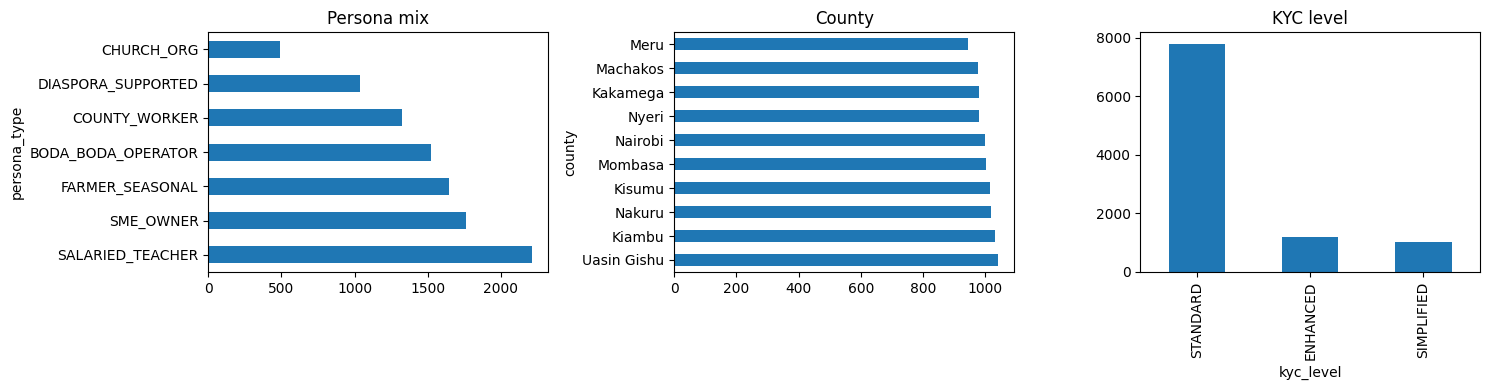

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
members['persona_type'].value_counts().plot.barh(ax=axes[0], title='Persona mix')
members['county'].value_counts().plot.barh(ax=axes[1], title='County')
members['kyc_level'].value_counts().plot.bar(ax=axes[2], title='KYC level')
plt.tight_layout()


In [8]:
members['declared_monthly_income_kes'].describe().round(0)


count     10000.0
mean      92988.0
std       66900.0
min       11251.0
25%       55195.0
50%       74008.0
75%      104065.0
max      588640.0
Name: declared_monthly_income_kes, dtype: float64

## 3. Accounts

Each member typically has multiple accounts spanning BOSA deposits, FOSA savings/current, share capital, loan accounts, and mobile-money wallets. Synthetic SOURCE / SINK accounts absorb external flows so every transaction reconciles.

<!-- KSS_ASSUMPTIONS -->
**Decisions encoded here.**

- **BOSA vs FOSA vs share capital vs loan account.** These are *distinct*
  account types with different semantics:
  - `BOSA_DEPOSIT` — long-term, non-withdrawable, drives loan eligibility.
  - `FOSA_SAVINGS` / `FOSA_CURRENT` — transactional, withdrawable.
  - `SHARE_CAPITAL` — ownership equity, non-withdrawable; never debited by a
    `FOSA_CASH_WITHDRAWAL` or `MPESA_CASHOUT`.
  - `LOAN_ACCOUNT` — `current_balance_kes` is **positive outstanding
    principal**. Disbursement increases it; repayment decreases it; a fully
    repaid loan reads zero. This avoids negative-liability sign confusion.
- **Why `SOURCE_ACCOUNT` and `SINK_ACCOUNT` exist.** External money
  (employer payroll, remittances, cash entering a branch, supplier
  payments leaving the system) has to debit or credit *something* to keep
  the ledger double-entry. Source / sink accounts absorb those flows.
  They may carry negative or unbounded positive balances and are
  **excluded from member-balance validation**. Public IDs are generic
  (e.g. `EXT_SRC_041`); the spec forbids leaking labels like
  `ILLICIT_CASH_SOURCE` into exported files.
- **Required account setup** for an individual member: 1 `BOSA_DEPOSIT`,
  1 `FOSA_SAVINGS` or `FOSA_CURRENT`, 1 `SHARE_CAPITAL`, optionally 1
  `MPESA_WALLET`, plus zero or more `LOAN_ACCOUNT`s.

The SASRA distinction between deposit-taking SACCOs (177, FOSA-capable) and
specified non-deposit-taking SACCOs (178, BOSA-only) is the reason both
account types exist as first-class concepts even though the v0.1 institution
mix simulates DT-style SACCOs.

### v0.2 support entities (new files, additive)

`accounts.csv` no longer stands alone. v0.2 promotes the infrastructure
that members and accounts attach to into authoritative tabular files
alongside `nodes.csv` / `graph_edges.csv`:

| File | Role | Key columns (excerpt) |
|---|---|---|
| `institutions.csv` | One row per SACCO. | `institution_id`, `archetype`, `county`, `urban_rural`, `digital_maturity`, `cash_intensity`, `loan_guarantor_intensity` |
| `branches.csv` | Physical branches a member or `CASH_BRANCH` transaction can resolve to. | `branch_id`, `institution_id`, `county`, `urban_rural` |
| `agents.csv` | M-Pesa / SACCO agent endpoints used by `CASH_AGENT` and `MPESA_*` rails. | `agent_id`, `institution_id`, `county`, `agent_type` |
| `employers.csv` | Payroll counterparties used by `PAYROLL_CHECKOFF`. | `employer_id`, `sector`, `payroll_day`, `county` |
| `devices.csv` | Mobile / web devices recorded for digital channels. | `device_id`, `device_type`, `os_family`, `is_shared` |

Foreign keys must resolve: every `institution_id` referenced by a member,
branch, agent, or employer; every `device_id` referenced by a transaction;
every agent/branch attached to a cash transaction. The validator's
`support_entity_validation` block aborts export on any unresolved FK or
duplicate primary key. `nodes.csv` / `graph_edges.csv` continue to be
emitted as graph projections over the same entities.


In [9]:
accounts = pd.read_csv(DATASET_DIR / 'accounts.csv')
print(f'{len(accounts):,} accounts')
accounts['account_type'].value_counts()


41,003 accounts


account_type
BOSA_DEPOSIT      9819
SHARE_CAPITAL     9509
MPESA_WALLET      9311
FOSA_CURRENT      5182
FOSA_SAVINGS      4818
LOAN_ACCOUNT      2352
SOURCE_ACCOUNT       6
SINK_ACCOUNT         6
Name: count, dtype: int64

In [10]:
member_accounts = accounts[accounts['account_owner_type'] == 'MEMBER']
member_accounts.groupby('account_type')['current_balance_kes'].agg(['count','mean','median','sum']).round(0)


,count,mean,median,sum
account_type,,,,
BOSA_DEPOSIT,9819,109411.0,104583.0,1.074309e+09
FOSA_CURRENT,5182,504501.0,497749.0,2.614326e+09
FOSA_SAVINGS,4818,458457.0,479543.0,2.208845e+09
LOAN_ACCOUNT,2352,42505.0,26070.0,9.997080e+07
MPESA_WALLET,9311,80672.0,80654.0,7.511389e+08
SHARE_CAPITAL,9509,10520.0,10488.0,1.000334e+08


## 4. Transactions

The normal-transaction engine produces a Kenya-like mix: payroll check-off, M-Pesa paybill, agent cash deposits, PesaLink transfers, wallet P2P, loan disbursements/repayments, household spend, and seasonal flows.

<!-- KSS_ASSUMPTIONS -->
**Decisions encoded here.**

- **Rails are explicit, not collapsed into "transfer".** The taxonomy
  separates `SACCO_INTERNAL`, `MPESA`, `AIRTEL_MONEY`, `PESALINK`, `EFT`,
  `RTGS`, `CASH_BRANCH`, `CASH_AGENT`, `PAYROLL_CHECKOFF`, `REMITTANCE`.
  This split is required because they have very different AML profiles —
  PesaLink is real-time and useful for rapid pass-through; RTGS / KEPSS is
  for treasury (~KSh 5M average payment); cash via agent allows
  third-party deposits the original depositor cannot be identified for.
- **Calendar effects (`calendar.yaml`).**
  - `payday_days = [24..31]` — formal salary clusters at month-end and the
    distribution validator requires ≥70% of salary events fall in this
    window.
  - `school_fee_months = [1, 5, 8]` — household outflow spike for fees.
  - `harvest_months = [3, 4, 8, 9, 12]` — `FARMER_SEASONAL` income lumps.
  - `december_spend_multiplier = 1.5` — holiday remittance / spend bump.
  - `weekend_wallet_multiplier = 1.3`, `monday_sme_deposit_multiplier = 1.4`.
- **Rural / urban channel mix.** `urban_rural` on each member biases
  channel selection: rural members are ≥1.2x more likely to use
  `CASH_BRANCH` / `CASH_AGENT`; urban members lean wallet / app / USSD.
- **No label leakage in `transactions.csv`.** The spec forbids any of
  `is_suspicious`, `typology`, `pattern_id`, `alert_id`,
  `source_is_illicit`, `synthetic_flag` in this file. Labels live
  exclusively in `alerts_truth.csv`.
- **Operational zero-amount events** (`KYC_REFRESH`,
  `ACCOUNT_REACTIVATION`) are emitted as ledger rows because future
  typologies depend on dormant-reactivation timing. `SYSTEM_CORRECTION`
  is dev-only and absent from released benchmarks unless the manifest
  declares otherwise.


In [11]:
transactions = pd.read_csv(DATASET_DIR / 'transactions.csv', parse_dates=['timestamp'])
print(f"{len(transactions):,} transactions over {transactions['timestamp'].min()} -> {transactions['timestamp'].max()}")
transactions.head(3)


510,980 transactions over 2024-01-01 09:00:00+03:00 -> 2024-12-31 23:59:59+03:00


,txn_id,timestamp,institution_id,account_id_dr,account_id_cr,member_id_primary,txn_type,rail,channel,provider,...,narrative,reference,branch_id,agent_id,device_id,geo_bucket,batch_id,balance_after_dr_kes,balance_after_cr_kes,is_reversal
0,TXN000000000001,2024-01-01 09:00:00+03:00,INST0002,ACC00038643,ACC00002039,MEM0000527,BUSINESS_SETTLEMENT_IN,MPESA,PAYBILL,MPESA,...,Business Settlement In,MPESA_D8601E898810,BRANCH000004,NaN,DEVICE000527,Kakamega,NaN,-15228.72,48108.72,False
1,TXN000000000002,2024-01-01 09:00:00+03:00,INST0004,ACC00038643,ACC00008879,MEM0002293,BUSINESS_SETTLEMENT_IN,MPESA,PAYBILL,MPESA,...,Business Settlement In,MPESA_0514F5C01AED,BRANCH000007,NaN,DEVICE002293,Kisumu,NaN,-24146.88,11673.16,False
2,TXN000000000003,2024-01-01 09:00:00+03:00,INST0002,ACC00038642,ACC00012403,MEM0003201,BUSINESS_SETTLEMENT_IN,MPESA,PAYBILL,MPESA,...,Business Settlement In,MPESA_F1C8A43E7085,BRANCH000003,NaN,DEVICE003201,Meru,NaN,-24702.25,33314.25,False


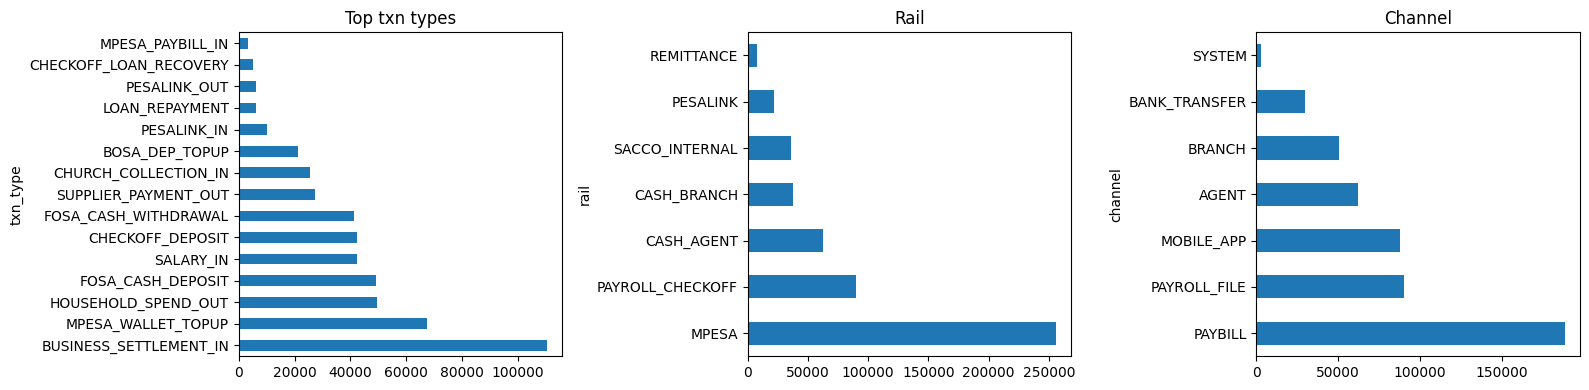

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
transactions['txn_type'].value_counts().head(15).plot.barh(ax=axes[0], title='Top txn types')
transactions['rail'].value_counts().plot.barh(ax=axes[1], title='Rail')
transactions['channel'].value_counts().plot.barh(ax=axes[2], title='Channel')
plt.tight_layout()


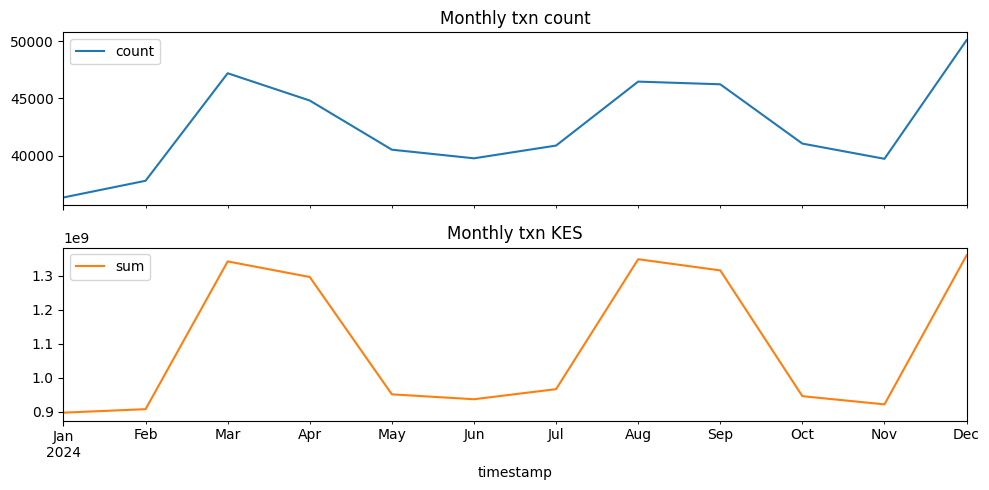

In [13]:
monthly = transactions.set_index('timestamp')['amount_kes'].resample('MS').agg(['count','sum'])
monthly.plot(subplots=True, figsize=(10, 5), title=['Monthly txn count','Monthly txn KES'])
plt.tight_layout()


## 5. Loans and guarantors

Loans link to a `LOAN_ACCOUNT`, are guaranteed by other SACCO members, and post a full lifecycle of disbursement / repayment / arrears transactions back into `transactions.csv`.

<!-- KSS_ASSUMPTIONS -->
**Decisions encoded here.**

- **Six loan products** (`products.yaml`), each with a deposit multiplier
  and guarantor requirement: `DEVELOPMENT_LOAN` (3.0x, guarantors
  required), `BIASHARA_LOAN` (2.5x, required), `ASSET_FINANCE` (3.0x,
  required), `SCHOOL_FEES_LOAN` (2.0x, optional), `EMERGENCY_LOAN` (1.5x,
  optional), `SALARY_ADVANCE` (1.0x, none).
- **Deposit-multiple rule.** Approved principal cannot exceed
  `deposit_multiplier × member's BOSA balance at application`. The
  research report anchors this to the Kenya Police SACCO FAQ ("borrow up
  to three times savings"); the simulator also enforces the Kenyan
  two-thirds net-pay rule on payroll-attachable income.
- **Guarantor mechanics.** Guarantors must be active SACCO members with
  sufficient deposits to pledge; each guarantor's
  `guarantor_capacity_remaining_kes` is decremented at pledge and restored
  at release. Relationship type (`COWORKER`, `FAMILY`, `CHURCH_MEMBER`,
  …) is captured to support future guarantor-ring detection.
- **Repayment routes.** `PAYROLL_CHECKOFF` (the dominant mode for salaried
  members), `MANUAL_FOSA_TRANSFER`, `MPESA_PAYBILL`, or `CASH_BRANCH`.
  Each repayment posts a `LOAN_REPAYMENT` ledger row that decreases
  outstanding principal — the balance engine refuses to repay more than
  is owed.


In [14]:
loans      = pd.read_csv(DATASET_DIR / 'loans.csv', parse_dates=['application_date','approval_date','disbursement_date'])
guarantors = pd.read_csv(DATASET_DIR / 'guarantors.csv')
print(f'{len(loans):,} loans, {len(guarantors):,} guarantee rows')
loans['performing_status'].value_counts()


2,352 loans, 3,372 guarantee rows


performing_status
CURRENT       1457
CLOSED         700
IN_ARREARS     153
DEFAULTED       42
Name: count, dtype: int64

In [15]:
loans['principal_kes'].describe().round(0)


count      2352.0
mean      83152.0
std       51416.0
min       10052.0
25%       41993.0
50%       72878.0
75%      111375.0
max      224373.0
Name: principal_kes, dtype: float64

## 6. The labels — `alerts_truth.csv`

Ground-truth suspicious behaviour lives **only** in `alerts_truth.csv`. The generator deliberately does **not** leak label columns into feature files (members / accounts / transactions / edges). The two implemented v0.1 typologies are:

- `STRUCTURING` — sub-threshold deposits to evade reporting limits
- `RAPID_PASS_THROUGH` — funds in and out within a short window with high exit ratios

<!-- KSS_ASSUMPTIONS -->
**Decisions encoded here.**

- **Three typologies in v0.2.** The two v0.1 typologies are unchanged;
  v0.2 adds one SACCO-credit-engine typology (spec §9.1):

  - `STRUCTURING` — 5–12 sub-threshold deposits (KES 70k–99k each) over
    a 2–7 day window into a member's FOSA via `CASH_BRANCH`,
    `CASH_AGENT`, or `MPESA`. Candidate personas: `SME_OWNER`,
    `BODA_BODA_OPERATOR`, `DIASPORA_SUPPORTED`.
  - `RAPID_PASS_THROUGH` — single inflow of KES 100k–750k followed
    within 1–48h by 2–8 outflows draining 75–98% of the value to
    unrelated counterparties. Candidate personas: `DIASPORA_SUPPORTED`,
    `SME_OWNER`, `CHURCH_ORG`.
  - `FAKE_AFFORDABILITY_BEFORE_LOAN` *(v0.2 only)* — within the 30-day
    lookback before a loan application, 2–5 temporary non-salary
    external credits (KES 25k–150k each, on `REMITTANCE`, `MPESA`,
    `PESALINK`, or `CASH_BRANCH`) push the apparent affordability
    upward: external-credit share ≥ 0.55 of inflows and balance growth
    ≥ KES 50k. Candidate personas: `SME_OWNER`, `DIASPORA_SUPPORTED`,
    `COUNTY_WORKER`, `SALARIED_TEACHER`. Eligible products:
    `DEVELOPMENT_LOAN`, `SCHOOL_FEES_LOAN`, `BIASHARA_LOAN`. The
    deterministic baseline rule for this typology is **expected to have
    low precision** — legitimate large remittances ahead of a loan are
    common — so false positives are an intended ambiguity, not a
    validation failure (spec §9.1).

- **Anti-leakage discipline (spec §13).** Label columns are forbidden in
  feature files. The validator (`validation.forbid_label_leakage = true`)
  fails the run if any of these appear outside `alerts_truth.csv`:

  | File | Forbidden columns |
  |---|---|
  | `transactions.csv` | `is_suspicious`, `typology`, `pattern_id`, `alert_id`, `source_is_illicit`, `synthetic_flag` |
  | `members.csv` | `criminal_flag`, `shell_flag`, `suspicious_member`, `injected_typology` |
  | `accounts.csv` | `mule_account_flag`, `laundering_account_flag` |
  | `loans.csv` | typology / pattern markers of any kind |

- **Behavioural overlay, not cartoon criminals.** Suspicious members
  also produce normal traffic; suspicious amounts overlap legitimate
  high-end SME / church / farmer behaviour; suspicious accounts are
  generally not freshly created; suspicious counterparties are not all
  unique one-off nodes. The v0.2 fake-affordability typology specifically
  requires that suspicious members retain ≥ 50% normal transaction
  share (spec §12 Milestone 9 acceptance gate).

- **Stage labels** distinguish `PLACEMENT`, `LAYERING`, `INTEGRATION`,
  and `PATTERN_SUMMARY` — the last is one row per injected pattern,
  required by the validator to exist for every suspicious pattern. For
  `FAKE_AFFORDABILITY_BEFORE_LOAN`, every suspicious pre-application
  credit gets its own `alerts_truth` row and the loan account / member
  receives pattern context through additional rows.

- **Suspicious-member ratio target = 1%** (`world.suspicious_member_ratio
  = 0.01`), with a tolerance of ±0.2% enforced by distribution
  validation.


In [16]:
alerts = pd.read_csv(DATASET_DIR / 'alerts_truth.csv', parse_dates=['start_timestamp','end_timestamp'])
print(f"{len(alerts):,} alert rows across {alerts['pattern_id'].nunique()} patterns and {alerts['member_id'].nunique()} members")
alerts.head(3)


768 alert rows across 100 patterns and 100 members


,alert_id,pattern_id,typology,entity_type,entity_id,member_id,account_id,txn_id,edge_id,start_timestamp,end_timestamp,severity,truth_label,stage,explanation_code
0,ALT00000001,PAT00000001,STRUCTURING,TRANSACTION,TXN000000187919,MEM0006657,ACC00025746,TXN000000187919,NaN,2024-05-23 09:00:00+03:00,2024-05-23 09:00:00+03:00,HIGH,True,PLACEMENT,STRUCTURED_SUB_THRESHOLD_DEPOSITS
1,ALT00000002,PAT00000001,STRUCTURING,TRANSACTION,TXN000000188376,MEM0006657,ACC00025746,TXN000000188376,NaN,2024-05-23 12:00:00+03:00,2024-05-23 12:00:00+03:00,HIGH,True,PLACEMENT,STRUCTURED_SUB_THRESHOLD_DEPOSITS
2,ALT00000003,PAT00000001,STRUCTURING,TRANSACTION,TXN000000190128,MEM0006657,ACC00025746,TXN000000190128,NaN,2024-05-24 12:00:00+03:00,2024-05-24 12:00:00+03:00,HIGH,True,PLACEMENT,STRUCTURED_SUB_THRESHOLD_DEPOSITS


In [17]:
alerts.groupby(['typology','stage','explanation_code']).size().unstack(fill_value=0)


explanation_code                                HIGH_EXIT_RATIO  \
typology                       stage                              
FAKE_AFFORDABILITY_BEFORE_LOAN INTEGRATION                    0   
                               PATTERN_SUMMARY                0   
                               PLACEMENT                      0   
RAPID_PASS_THROUGH             LAYERING                     144   
                               PATTERN_SUMMARY                0   
                               PLACEMENT                      0   
STRUCTURING                    PATTERN_SUMMARY                0   
                               PLACEMENT                      0   

explanation_code                                PRE_LOAN_AFFORDABILITY_BOOST  \
typology                       stage                                           
FAKE_AFFORDABILITY_BEFORE_LOAN INTEGRATION                                68   
                               PATTERN_SUMMARY                             0   
                               PLACEMENT                                 117   
RAPID_PASS_THROUGH             LAYERING                                    0   
                               PATTERN_SUMMARY                             0   
                               PLACEMENT                                   0   
STRUCTURING                    PATTERN_SUMMARY                             0   
                               PLACEMENT                                   0   

explanation_code                                RAPID_IN_OUT_MOVEMENT  \
typology                       stage                                    
FAKE_AFFORDABILITY_BEFORE_LOAN INTEGRATION                          0   
                               PATTERN_SUMMARY                      0   
                               PLACEMENT                            0   
RAPID_PASS_THROUGH             LAYERING                            25   
                               PATTERN_SUMMARY                      0   
                               PLACEMENT                           33   
STRUCTURING                    PATTERN_SUMMARY                      0   
                               PLACEMENT                            0   

explanation_code                                STRUCTURED_SUB_THRESHOLD_DEPOSITS  \
typology                       stage                                                
FAKE_AFFORDABILITY_BEFORE_LOAN INTEGRATION                                      0   
                               PATTERN_SUMMARY                                  0   
                               PLACEMENT                                        0   
RAPID_PASS_THROUGH             LAYERING                                         0   
                               PATTERN_SUMMARY                                  0   
                               PLACEMENT                                        0   
STRUCTURING                    PATTERN_SUMMARY                                  0   
                               PLACEMENT                                      281   

explanation_code                                SUSPICIOUS_PATTERN_SUMMARY  
typology                       stage                                        
FAKE_AFFORDABILITY_BEFORE_LOAN INTEGRATION                               0  
                               PATTERN_SUMMARY                          34  
                               PLACEMENT                                 0  
RAPID_PASS_THROUGH             LAYERING                                  0  
                               PATTERN_SUMMARY                          33  
                               PLACEMENT                                 0  
STRUCTURING                    PATTERN_SUMMARY                          33  
                               PLACEMENT                                 0

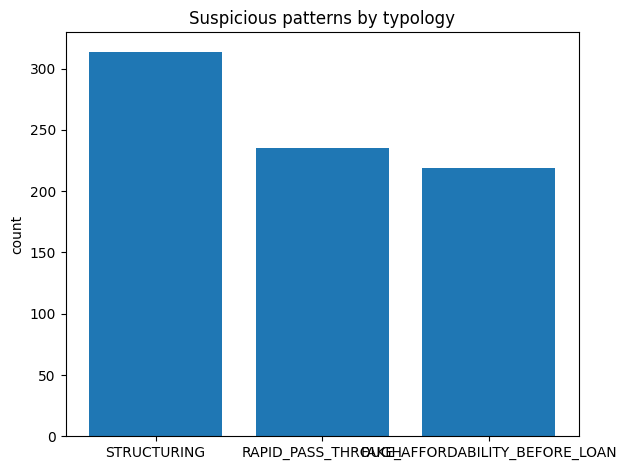

In [18]:
counts = alerts['typology'].value_counts()
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values, color='#1f77b4')
ax.set_title('Suspicious patterns by typology')
ax.set_ylabel('count')
plt.tight_layout()


## 7. Official splits

`split_manifest.json` is the source of truth for member-level and pattern-level train / validation / test assignment. The generator guarantees zero member or pattern leakage across splits.

<!-- KSS_ASSUMPTIONS -->
**Decisions encoded here.**

- **Member-level partition.** Every member is assigned to exactly one of
  `train` / `val` / `test`. All transactions, accounts, loans, and
  guarantor edges for a member follow that member's split — there is no
  edge that crosses splits for the same actor.
- **Pattern-level disjointness.** Every suspicious pattern (and therefore
  every `pattern_id` in `alerts_truth.csv`) belongs to exactly one split.
  This blocks the most subtle leakage path, where two halves of the same
  injected typology end up on opposite sides of the train / test
  boundary.
- **Anti-leakage gates** are recomputed on every run and recorded in
  `validation_report.json` under `label_validation` and
  `distribution_validation`. A failed gate aborts export.


In [19]:
split_manifest = json.loads((DATASET_DIR / 'split_manifest.json').read_text())
print('Split counts:')
print(json.dumps(split_manifest['counts'], indent=2))
print('\nLeakage checks:')
print(json.dumps(split_manifest['checks'], indent=2))


Split counts:
{
  "alerts_truth": {
    "test": 100,
    "train": 592,
    "validation": 76
  },
  "members": {
    "test": 1512,
    "train": 6992,
    "validation": 1496
  },
  "patterns": {
    "test": 14,
    "train": 75,
    "validation": 11
  },
  "transactions": {
    "test": 77293,
    "train": 356700,
    "validation": 76987
  }
}

Leakage checks:
{
  "institution_split_distribution": {
    "INST0001": {
      "counts": {
        "test": 316,
        "train": 1628,
        "validation": 345
      },
      "max_split": "train",
      "max_split_share": 0.7112
    },
    "INST0002": {
      "counts": {
        "test": 264,
        "train": 1187,
        "validation": 245
      },
      "max_split": "train",
      "max_split_share": 0.6999
    },
    "INST0003": {
      "counts": {
        "test": 267,
        "train": 1171,
        "validation": 254
      },
      "max_split": "train",
      "max_split_share": 0.6921
    },
    "INST0004": {
      "counts": {
        "test": 329

In [20]:
member_split = pd.Series(split_manifest['member_id_to_split'], name='split')
member_split.value_counts()


split
train         6992
test          1512
validation    1496
Name: count, dtype: int64

## 8. Reproduce the rule baseline

`baseline_model_results.json` records the precision / recall the shipped detection rules achieve against the truth labels. Load it and confirm we understand it.

In [21]:
baseline = json.loads((DATASET_DIR / 'baseline_model_results.json').read_text())
print(json.dumps({k: baseline[k] for k in baseline if k != 'benchmark_checks'}, indent=2)[:2000])


{
  "baseline_name": "deterministic_v0_2_rules",
  "description": "Rule baseline using exported structuring, rapid-pass-through, and fake-affordability definitions.",
  "macro_precision": 0.6008,
  "macro_recall": 0.9296,
  "per_typology": {
    "FAKE_AFFORDABILITY_BEFORE_LOAN": {
      "candidate_member_count": 137,
      "false_negative_member_count": 1,
      "false_negative_member_ids": [
        "MEM0009532"
      ],
      "false_positive_member_count": 104,
      "false_positive_member_ids": [
        "MEM0000057",
        "MEM0000068",
        "MEM0000073",
        "MEM0000183",
        "MEM0000213",
        "MEM0000277",
        "MEM0000350",
        "MEM0000404",
        "MEM0000506",
        "MEM0000533",
        "MEM0000831",
        "MEM0000977",
        "MEM0001041",
        "MEM0001185",
        "MEM0001231",
        "MEM0001240",
        "MEM0001266",
        "MEM0001394",
        "MEM0001410",
        "MEM0001413",
        "MEM0001542",
        "MEM0001815",
        "ME

## 9. A simple member-level ML baseline

We will:
1. Aggregate transactions per member into ~10 features.
2. Label each member suspicious if they appear in `alerts_truth.member_id`.
3. Use the official split for training and evaluation.
4. Train a logistic regression on standardized features.
5. Report PR-AUC, ROC-AUC, and precision / recall at a chosen alert volume.

This is intentionally crude — the point is to show the wiring, not to win the benchmark.

In [22]:
# 9.1 Per-member features from transactions
tx = transactions.dropna(subset=['member_id_primary']).copy()
tx['date'] = tx['timestamp'].dt.date

agg = tx.groupby('member_id_primary').agg(
    txn_count            =('txn_id', 'count'),
    amount_sum           =('amount_kes', 'sum'),
    amount_mean          =('amount_kes', 'mean'),
    amount_std           =('amount_kes', 'std'),
    amount_max           =('amount_kes', 'max'),
    distinct_counterparty=('counterparty_id_hash', 'nunique'),
    distinct_channel     =('channel', 'nunique'),
    distinct_rail        =('rail', 'nunique'),
    distinct_days        =('date', 'nunique'),
).fillna(0.0)

agg['txns_per_active_day'] = agg['txn_count'] / agg['distinct_days'].clip(lower=1)
agg['cash_share'] = (
    tx[tx['rail'].isin(['CASH_BRANCH','CASH_AGENT'])]
      .groupby('member_id_primary').size()
      .reindex(agg.index, fill_value=0) / agg['txn_count'].clip(lower=1)
)
agg['mobile_share'] = (
    tx[tx['rail'].isin(['MPESA','AIRTEL_MONEY'])]
      .groupby('member_id_primary').size()
      .reindex(agg.index, fill_value=0) / agg['txn_count'].clip(lower=1)
)
agg.head()


,txn_count,amount_sum,amount_mean,amount_std,amount_max,distinct_counterparty,distinct_channel,distinct_rail,distinct_days,txns_per_active_day,cash_share,mobile_share
member_id_primary,,,,,,,,,,,,
MEM0000001,52,196503.26,3778.908846,2345.397622,8594.91,9,3,4,50,1.040000,0.769231,0.211538
MEM0000002,43,232478.07,5406.466744,3281.189459,11473.59,8,3,4,43,1.000000,0.790698,0.162791
MEM0000003,45,1133862.99,25196.955333,23697.715973,65094.51,4,3,3,33,1.363636,0.000000,0.400000
MEM0000004,49,1069243.82,21821.302449,21438.064452,60403.55,4,4,3,37,1.324324,0.020408,0.489796
MEM0000005,53,358890.80,6771.524528,15067.894465,111837.00,9,5,4,52,1.019231,0.773585,0.169811


In [23]:
# 9.2 Labels and split assignment
agg = agg.join(member_split, how='left')
agg['split'] = agg['split'].fillna('train')
suspicious_members = set(alerts['member_id'].dropna().astype(str))
agg['y'] = agg.index.astype(str).isin(suspicious_members).astype(int)

print('Class balance overall:', agg['y'].mean().round(4))
agg.groupby('split')['y'].agg(['count','sum','mean']).round(4)


Class balance overall: 0.01


,count,sum,mean
split,,,
test,1512,14,0.0093
train,6992,75,0.0107
validation,1496,11,0.0074


In [24]:
# 9.3 Train logistic regression on the official splits
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, precision_score, recall_score)

feature_cols = [c for c in agg.columns if c not in {'split','y'}]
X_train = agg.loc[agg['split'] == 'train', feature_cols].values
y_train = agg.loc[agg['split'] == 'train', 'y'].values
X_test  = agg.loc[agg['split'] == 'test',  feature_cols].values
y_test  = agg.loc[agg['split'] == 'test',  'y'].values

scaler = StandardScaler().fit(X_train)
clf = LogisticRegression(max_iter=2000, class_weight='balanced').fit(scaler.transform(X_train), y_train)
scores = clf.predict_proba(scaler.transform(X_test))[:, 1]

print(f'Test PR-AUC : {average_precision_score(y_test, scores):.4f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, scores):.4f}')

n_test_alerts = max(int(y_test.sum() * 1.5), 50)
threshold = sorted(scores, reverse=True)[min(n_test_alerts, len(scores)) - 1]
y_pred = (scores >= threshold).astype(int)
print(f'\n@ top-{n_test_alerts} flagged members:')
print(f'  precision: {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'  recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}')


Test PR-AUC : 0.8669
Test ROC-AUC: 0.9969

@ top-50 flagged members:
  precision: 0.2600
  recall   : 0.9286


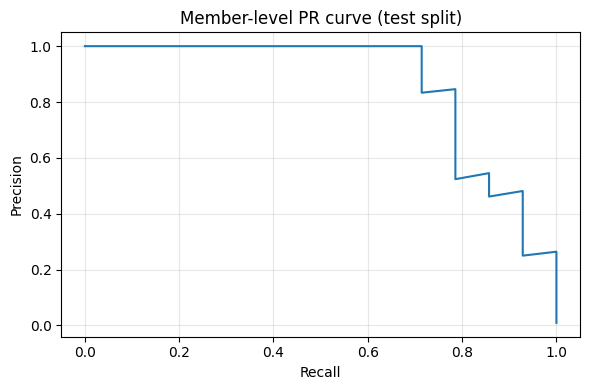

In [25]:
# 9.4 Plot precision-recall curve
prec, rec, _ = precision_recall_curve(y_test, scores)
plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Member-level PR curve (test split)')
plt.grid(alpha=0.3); plt.tight_layout()


## 10. Graph view — ego-network of a suspicious member

`nodes.csv` and `graph_edges.csv` give you a typed heterogeneous graph (`MEMBER`, `ACCOUNT`, `INSTITUTION`, `BRANCH`, `AGENT`, `EMPLOYER`, `DEVICE`, `SOURCE`, `SINK`) with relationships like `HAS_ACCOUNT`, `EMPLOYED_BY`, `GUARANTEES`, `SOURCE_FUNDS_ACCOUNT`, etc.

In [26]:
import networkx as nx

nodes = pd.read_csv(DATASET_DIR / 'nodes.csv')
edges = pd.read_csv(DATASET_DIR / 'graph_edges.csv')
print(f'{len(nodes):,} nodes, {len(edges):,} edges')
edges['edge_type'].value_counts().head(10)


61,128 nodes, 363,222 edges


edge_type
SOURCE_FUNDS_ACCOUNT               115866
ACCOUNT_PAYS_SINK                  115866
ACCOUNT_BELONGS_TO_INSTITUTION      40991
HAS_ACCOUNT                         31680
ACCOUNT_AT_BRANCH                   31680
USES_DEVICE                         10800
HAS_WALLET                           9311
EMPLOYED_BY                          3536
GUARANTEES                           3372
EMPLOYER_BELONGS_TO_INSTITUTION        60
Name: count, dtype: int64

In [27]:
target_member = alerts['member_id'].dropna().iloc[0]
target_node   = nodes.loc[nodes['entity_id'] == target_member, 'node_id'].iloc[0]
print('Target member:', target_member, 'node:', target_node)

G = nx.from_pandas_edgelist(edges, 'src_node_id', 'dst_node_id', edge_attr=['edge_type'], create_using=nx.MultiDiGraph)
ego = nx.ego_graph(G.to_undirected(as_view=True), target_node, radius=2)
print(f'Ego graph: {ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges')


Target member: MEM0006657 node: NODE00016782
Ego graph: 20 nodes, 37 edges


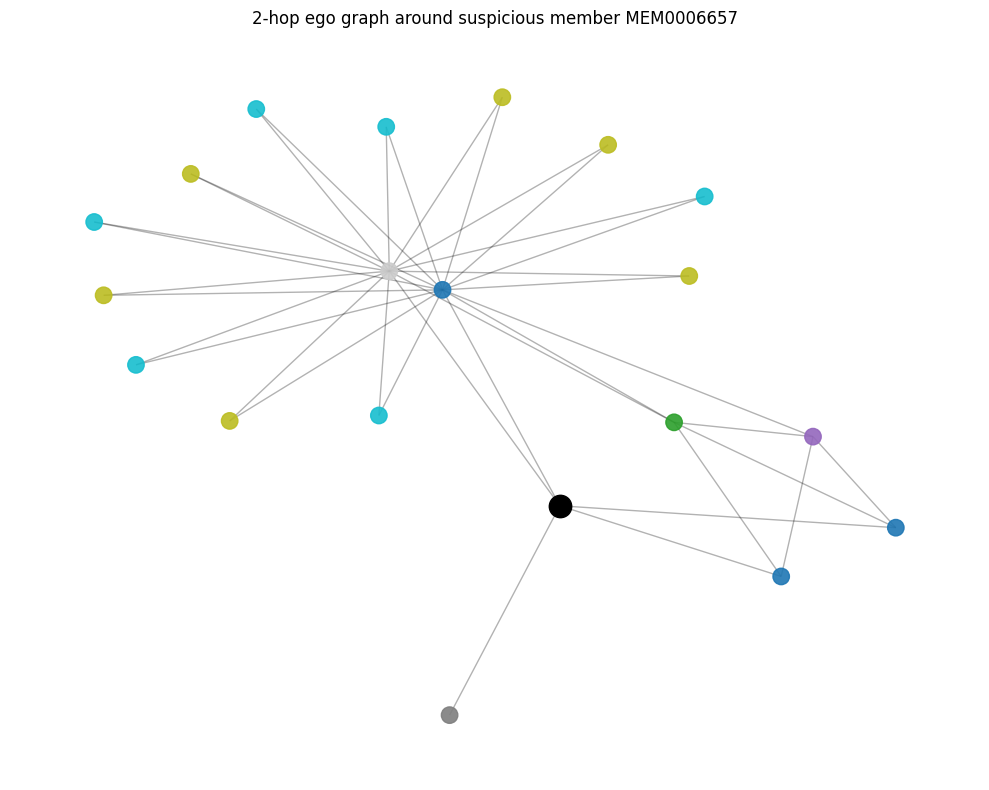

In [28]:
node_type = nodes.set_index('node_id')['node_type']
palette = {'MEMBER':'#d62728','ACCOUNT':'#1f77b4','INSTITUTION':'#2ca02c','BRANCH':'#9467bd',
           'AGENT':'#ff7f0e','EMPLOYER':'#8c564b','DEVICE':'#7f7f7f','SOURCE':'#17becf','SINK':'#bcbd22'}
colors = [palette.get(node_type.get(n, 'MEMBER'), '#cccccc') for n in ego.nodes]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(ego, seed=42, k=0.6)
nx.draw_networkx_nodes(ego, pos, node_color=colors, node_size=140, alpha=0.9)
nx.draw_networkx_edges(ego, pos, alpha=0.3, arrows=False)
nx.draw_networkx_nodes(ego, pos, nodelist=[target_node], node_color='black', node_size=260)
plt.title(f'2-hop ego graph around suspicious member {target_member}')
plt.axis('off'); plt.tight_layout()


<!-- KSS_ASSUMPTIONS -->
## 10b. Validation gates every release must pass

The generator refuses to write a dataset that fails any of these checks
(implemented in `validation/`, summarised in `validation_report.json`).
The v0.1 gates listed first are the foundation; the v0.2 gates below
them (spec §10) are additive and equally hard.

**v0.1 foundation gates**

- **Schema** — required files exist, columns present, primary keys
  unique, foreign keys resolve, enums valid, timestamps inside the
  simulation window.
- **Balance** — no member account goes negative; `balance_after_*` fields
  match the running ledger; loan disbursements equal loan principal;
  loan repayments never exceed outstanding balance. `SOURCE` /
  `SINK` accounts are explicitly excluded from this check.
- **Graph** — every member has at least one account; every account
  belongs to exactly one member, source, sink, or institution; every
  account / member referenced by a transaction appears in `nodes.csv`;
  every guarantor edge has a matching `guarantors.csv` row; every
  injected suspicious pattern forms a connected subgraph.
- **Label** — every suspicious transaction has `alerts_truth` coverage;
  every `alerts_truth.txn_id` exists in `transactions.csv`; every
  suspicious pattern has exactly one `PATTERN_SUMMARY` row; suspicious
  prevalence matches `world.suspicious_member_ratio` ± tolerance.
- **Distribution** — salary-day concentration ≥ 0.70 within the payday
  window; school-fee-month outflow spike present; December spend spike
  present; rural cash share > urban cash share; loan utilisation,
  per-member transaction counts, and structuring / pass-through counts
  all within configured bands.
- **Leakage** — no forbidden label column appears in any feature file;
  member and pattern IDs are disjoint across splits.

**v0.2 additions** (new sections inside `validation_report.json`)

- **`support_entity_validation`** — primary keys in `institutions.csv`,
  `branches.csv`, `agents.csv`, `employers.csv`, `devices.csv` are
  unique; every foreign key referenced from members, transactions, or
  graph edges resolves to an existing support row. Hard error on any
  duplicate or unresolved FK.
- **`device_validation`** — every `transactions.device_id` appears in
  `devices.csv` *and* `nodes.csv`; every `DEVICE` node has at least one
  `USES_DEVICE` edge; digital-channel device coverage is reported and
  warned on if unexpectedly low; the shared-device baseline is reported
  and warned on if unexpectedly high.
- **`institution_archetype_metrics`** — per-archetype member counts,
  channel mix, loan style, and split distribution. Warns if the
  archetype distribution is too concentrated.
- **`fake_affordability_validation`** — every
  `FAKE_AFFORDABILITY_BEFORE_LOAN` label resolves to existing loans,
  members, accounts, and transactions; suspicious members retain ≥ 50%
  normal transaction share; baseline rule TP / FP / FN counts are
  reported.
- **Benchmark / split** — `institution_split_max_share` is reported and
  warns if > 0.80 (so no single SACCO dominates a split); the multi-seed
  harness records per-typology precision/recall ranges and the v0.2
  release gate is **range ≤ 0.10 across configured seeds**.

Open `datasets/KENYA_SACCO_SIM_v02_10k_review_fix/validation_report.json`
to see every gate's pass / fail status for the run this notebook reads.



## 11. Where to go next

- **Stronger tabular baseline** — swap logistic regression for LightGBM / XGBoost; add inter-arrival times, deposit clustering, exit ratios.
- **Sequence models** — group transactions per member as ordered sequences and train a Transformer or LSTM.
- **Graph neural networks** — convert `nodes.csv` + `graph_edges.csv` into a heterogeneous PyG / DGL dataset and try R-GCN or HGT.
- **Per-typology evaluation** — split metrics by `typology` (STRUCTURING vs RAPID_PASS_THROUGH); train one detector per typology.
- **Threshold economics** — plot analyst workload vs. recall and pick an operating point.
- **Reproduce the validation harness** — open `validation_report.json` and verify each gate (schema, balance, FK, distribution, label, leakage) on your own re-runs.

See `dataset_card.md`, `feature_documentation.json`, and `known_limitations.md` in the dataset directory for the formal documentation.